In [9]:
import pandas as pd

# carregando datasets

customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
geolocation = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")

print("Datasets carregados com sucesso!")

Datasets carregados com sucesso!


In [10]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [11]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [12]:
customers.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [13]:
# traduzindo colunas do dataset customers

customers = customers.rename(columns={
    "customer_id": "id_cliente",
    "customer_unique_id": "id_unico_cliente",
    "customer_zip_code_prefix": "prefixo_cep",
    "customer_city": "cidade_cliente",
    "customer_state": "estado_cliente"
})

customers.head()


,id_cliente,id_unico_cliente,prefixo_cep,cidade_cliente,estado_cliente
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [18]:
import os
os.getcwd()

'c:\\Users\\augus\\OneDrive\\Documentos\\ecommerce-analytics-project\\notebooks'

In [25]:
from pathlib import Path

# caminho da raiz do projeto
project_root = Path.cwd().parent

# caminho correto da pasta processed
processed_path = project_root / "data" / "processed"

# se existir algo chamado processed que não seja pasta, remove
if processed_path.exists() and not processed_path.is_dir():
    processed_path.unlink()

# cria a pasta processed, se não existir
processed_path.mkdir(parents=True, exist_ok=True)

# salva o arquivo tratado
customers.to_csv(processed_path / "clientes_tratado.csv", index=False)

print("Arquivo clientes_tratado.csv salvo com sucesso!")

Arquivo clientes_tratado.csv salvo com sucesso!


In [26]:
# verificando valores nulos

customers.isnull().sum()

id_cliente          0
id_unico_cliente    0
prefixo_cep         0
cidade_cliente      0
estado_cliente      0
dtype: int64

In [27]:
# informações estatísticas

customers.describe()

,prefixo_cep
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [28]:
# quantidade de clientes por estado

customers["estado_cliente"].value_counts()

estado_cliente
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

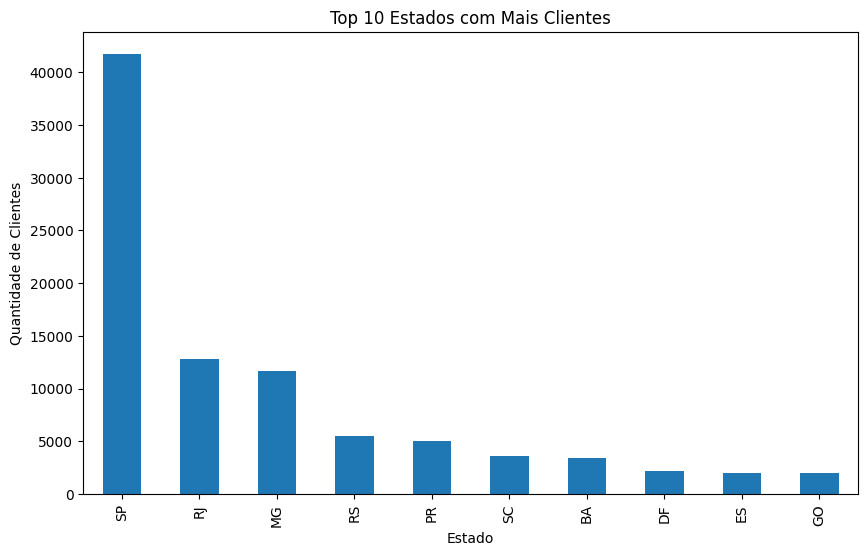

In [29]:
import matplotlib.pyplot as plt

# top 10 estados com mais clientes
top_estados = customers["estado_cliente"].value_counts().head(10)

# criando gráfico
plt.figure(figsize=(10,6))
top_estados.plot(kind="bar")

plt.title("Top 10 Estados com Mais Clientes")
plt.xlabel("Estado")
plt.ylabel("Quantidade de Clientes")

plt.show()

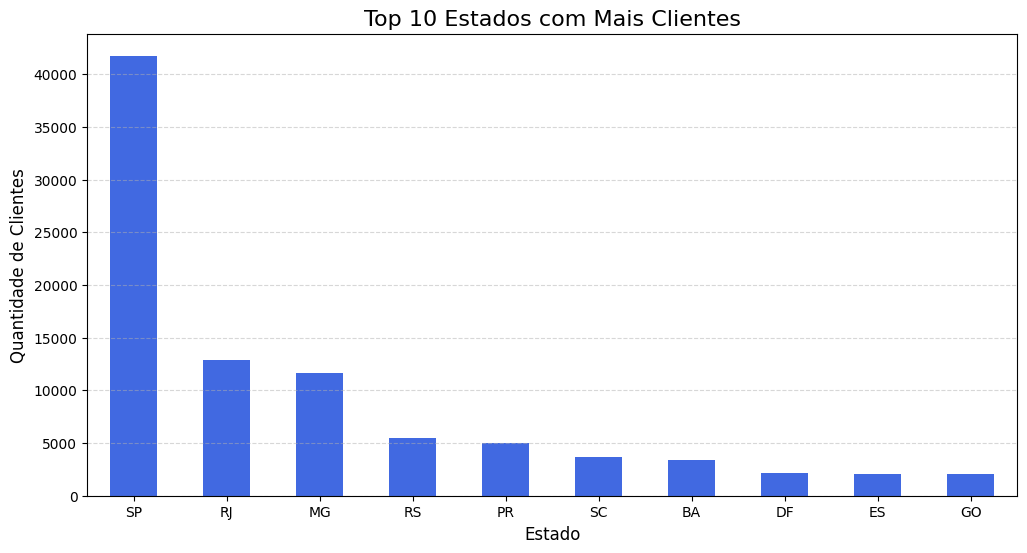

In [30]:
import matplotlib.pyplot as plt

# top 10 estados
top_estados = customers["estado_cliente"].value_counts().head(10)

# tamanho da figura
plt.figure(figsize=(12,6))

# gráfico
top_estados.plot(
    kind="bar",
    color="royalblue"
)

# personalização
plt.title("Top 10 Estados com Mais Clientes", fontsize=16)
plt.xlabel("Estado", fontsize=12)
plt.ylabel("Quantidade de Clientes", fontsize=12)

# rotacionando nomes
plt.xticks(rotation=0)

# grade
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [31]:
# top 10 cidades com mais clientes

top_cidades = customers["cidade_cliente"].value_counts().head(10)

top_cidades

cidade_cliente
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64

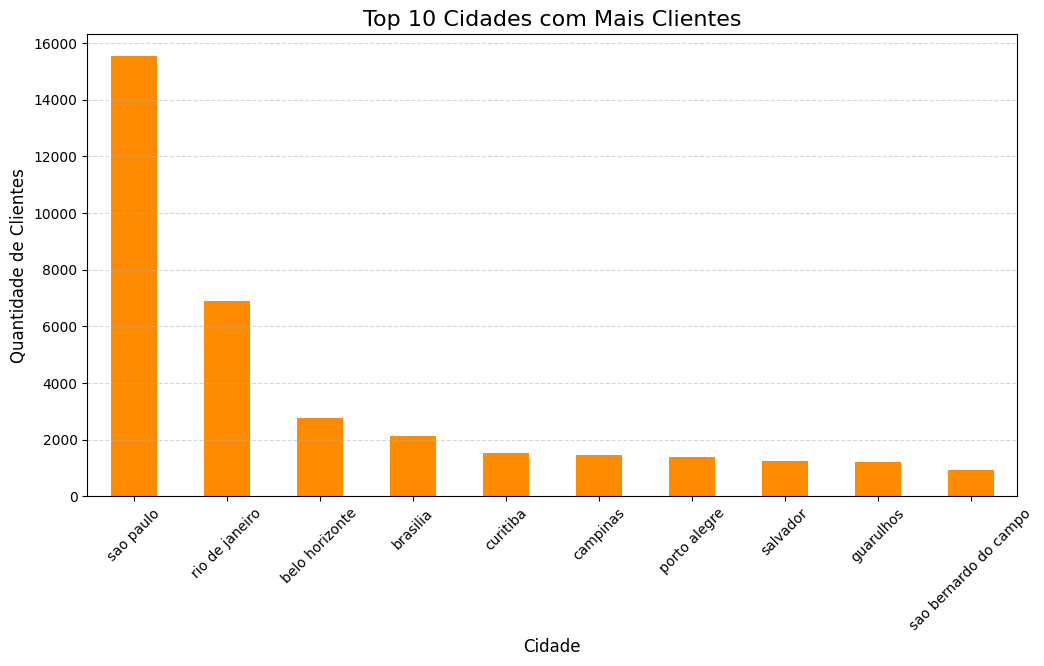

In [32]:
import matplotlib.pyplot as plt

# gráfico cidades
plt.figure(figsize=(12,6))

top_cidades.plot(
    kind="bar",
    color="darkorange"
)

plt.title("Top 10 Cidades com Mais Clientes", fontsize=16)
plt.xlabel("Cidade", fontsize=12)
plt.ylabel("Quantidade de Clientes", fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [33]:
# visualizando pedidos

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
